# Hotpot QA results

Load `run_saved/<id>/records.jsonl` and plot mean EM / F1 by arrangement and model.

Copy the run directories you care about from `runs/` into `run_saved/` (each folder needs a `records.jsonl`).

```bash
uv sync --extra notebook
```

Change `RUN_IDS` below to focus on one sweep (`None` loads every folder in `run_saved/`).


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from ctxlab.tracking import load_records

%matplotlib inline

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "legend.fontsize": 8,
    }
)

ARRANGEMENT_ORDER = [
    "no_context",
    "gold_only",
    "gold_first",
    "gold_middle",
    "gold_last",
    "shuffled",
    "similarity_first",
    "similarity_middle",
    "similarity_last",
]
POSITION_SERIES = {
    "gold block": ["gold_first", "gold_middle", "gold_last"],
    "similarity rank": ["similarity_first", "similarity_middle", "similarity_last"],
}


def repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in (cwd, *cwd.parents):
        if (candidate / "src" / "ctxlab").is_dir() and (candidate / "configs").is_dir():
            return candidate
    return cwd


ROOT = repo_root()
RUNS_DIR = ROOT / "run_saved"


def list_runs(runs_dir: Path = RUNS_DIR) -> pd.DataFrame:
    rows = []
    if not runs_dir.exists():
        return pd.DataFrame(columns=["run_id", "n_records", "n_examples", "arrangements", "models"])
    for path in sorted(p for p in runs_dir.iterdir() if p.is_dir()):
        if not (path / "records.jsonl").exists():
            continue
        records = load_records(path)
        summary: dict = {}
        sp = path / "summary.json"
        if sp.exists():
            summary = json.loads(sp.read_text())
        rows.append(
            {
                "run_id": path.name,
                "n_records": len(records),
                "n_examples": summary.get("n_examples"),
                "arrangements": ", ".join(sorted({r["arrangement"] for r in records})),
                "models": ", ".join(sorted({r["model"] for r in records})),
            }
        )
    return pd.DataFrame(rows)


def _gold_frac(meta: dict) -> float | None:
    positions = meta.get("gold_positions") or []
    n = int(meta.get("n_passages") or 0)
    if not positions or n <= 1:
        return None
    return sum(p / (n - 1) for p in positions) / len(positions)


def records_to_frame(records: list[dict], run_id: str) -> pd.DataFrame:
    rows = []
    for rec in records:
        meta = (rec.get("prompt") or {}).get("meta") or {}
        metrics = rec.get("metrics") or {}
        rows.append(
            {
                "run_id": run_id,
                "uid": rec.get("uid"),
                "question": rec.get("question"),
                "arrangement": rec.get("arrangement"),
                "model": rec.get("model"),
                "em": metrics.get("em"),
                "f1": metrics.get("f1"),
                "n_passages": meta.get("n_passages"),
                "n_gold": meta.get("n_gold"),
                "gold_frac": _gold_frac(meta),
            }
        )
    return pd.DataFrame(rows)


def load_runs(run_ids: list[str] | None = None) -> pd.DataFrame:
    if not RUNS_DIR.exists():
        return pd.DataFrame()
    available = sorted(p.name for p in RUNS_DIR.iterdir() if (p / "records.jsonl").exists())
    chosen = run_ids if run_ids is not None else available
    frames = [records_to_frame(load_records(RUNS_DIR / rid), rid) for rid in chosen]
    frames = [f for f in frames if not f.empty]
    return pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()


def order_arrangements(names) -> list[str]:
    names = list(names)
    known = [a for a in ARRANGEMENT_ORDER if a in names]
    rest = sorted(set(names) - set(known))
    return known + rest


def short_model(name: str) -> str:
    return str(name).rsplit("/", maxsplit=1)[-1]


def summarize(df: pd.DataFrame) -> pd.DataFrame:
    g = (
        df.dropna(subset=["em", "f1"])
        .groupby(["run_id", "arrangement", "model"], as_index=False)
        .agg(n=("em", "size"), em=("em", "mean"), f1=("f1", "mean"), f1_std=("f1", "std"))
    )
    g["em_se"] = (g["em"] * (1 - g["em"]) / g["n"]).pow(0.5)
    g["f1_se"] = (g["f1_std"] / g["n"].pow(0.5)).fillna(0.0)
    g["em_se"] = g["em_se"].fillna(0.0)
    return g


def _subplot_grid(n: int, *, width: float = 5.2, height: float = 3.8, sharey: bool = True):
    ncols = min(3, max(n, 1))
    nrows = max(1, math.ceil(max(n, 1) / ncols))
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(width * ncols, height * nrows), sharey=sharey, squeeze=False
    )
    flat = list(axes.ravel())
    for ax in flat[n:]:
        ax.set_visible(False)
    return fig, flat[: max(n, 1)]


def _style(ax) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    ax.set_axisbelow(True)


def plot_metric_bars(summary: pd.DataFrame, metric: str = "em") -> None:
    run_ids = list(dict.fromkeys(summary["run_id"]))
    fig, axes = _subplot_grid(len(run_ids))
    se_col = f"{metric}_se"
    for ax, run_id in zip(axes, run_ids, strict=False):
        sub = summary[summary["run_id"] == run_id]
        arrs = order_arrangements(sub["arrangement"].unique())
        models = sorted(sub["model"].unique())
        xs = list(range(len(arrs)))
        width = 0.8 / max(len(models), 1)
        for i, model in enumerate(models):
            msub = sub[sub["model"] == model].set_index("arrangement").reindex(arrs)
            offset = (i - (len(models) - 1) / 2) * width
            ys = msub[metric].fillna(0.0).tolist()
            yerr = [0.0 if pd.isna(v) else float(v) for v in msub[se_col].tolist()]
            ax.bar(
                [x + offset for x in xs],
                ys,
                width,
                yerr=yerr,
                capsize=3,
                label=short_model(model),
                zorder=2,
            )
        ax.set_xticks(xs)
        ax.set_xticklabels(arrs, rotation=35, ha="right")
        ax.set_title(run_id)
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(f"mean {metric}")
        ax.legend(loc="upper left")
        _style(ax)
    fig.suptitle(f"Mean {metric.upper()} by arrangement", y=1.02, fontsize=12)
    fig.tight_layout()


def plot_position_curves(summary: pd.DataFrame, metric: str = "em") -> None:
    drawn = False
    for title, arrs in POSITION_SERIES.items():
        rows = summary[summary["arrangement"].isin(arrs)]
        groups = list(rows.groupby(["run_id", "model"], sort=False))
        groups = [(key, g) for key, g in groups if set(arrs) <= set(g["arrangement"])]
        if not groups:
            continue
        drawn = True
        fig, ax = plt.subplots(figsize=(7.2, 4.2))
        for (run_id, model), g in groups:
            g = g.set_index("arrangement").reindex(arrs)
            ax.errorbar(
                range(len(arrs)),
                g[metric],
                yerr=g[f"{metric}_se"],
                marker="o",
                capsize=3,
                label=f"{run_id} · {short_model(model)}",
            )
        ax.set_xticks(range(len(arrs)))
        ax.set_xticklabels(["first", "middle", "last"])
        ax.set_ylim(0, 1.05)
        ax.set_ylabel(f"mean {metric}")
        ax.set_xlabel("evidence position")
        ax.set_title(f"{title}: mean {metric.upper()}")
        ax.legend(loc="best")
        _style(ax)
        fig.tight_layout()
    if not drawn:
        print("no first/middle/last series in the loaded runs")


def plot_example_heatmap(df: pd.DataFrame, run_id: str, model: str, metric: str = "em") -> None:
    sub = df[(df["run_id"] == run_id) & (df["model"] == model)]
    pivot = sub.pivot_table(index="uid", columns="arrangement", values=metric, aggfunc="mean")
    cols = order_arrangements(pivot.columns)
    pivot = pivot[cols]
    fig, ax = plt.subplots(figsize=(1.5 * len(cols) + 2.2, max(4.0, 0.11 * len(pivot))))
    im = ax.imshow(pivot.to_numpy(), aspect="auto", vmin=0, vmax=1, cmap="RdYlGn")
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, rotation=35, ha="right")
    ax.set_yticks([])
    ax.set_ylabel(f"{len(pivot)} examples")
    ax.set_title(f"{run_id} · {short_model(model)} · per-example {metric}")
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    fig.tight_layout()


In [2]:
catalog = list_runs()
if catalog.empty:
    raise FileNotFoundError(
        f"no records.jsonl under {RUNS_DIR} — copy a run folder from runs/ into run_saved/"
    )
catalog


,run_id,n_records,n_examples,arrangements,models
0,distractor_experiment_sweep_0,1600,200.0,"gold_first, gold_last, gold_only, shuffled, si...",gpt-4o-mini
1,distractor_experiment_sweep_1,1600,200.0,"gold_first, gold_last, gold_only, shuffled, si...",gpt-4o-mini
2,distractor_experiment_sweep_2,1600,200.0,"gold_first, gold_last, gold_only, shuffled, si...",gpt-4o-mini
3,distractor_experiment_sweep_3,1600,200.0,"gold_first, gold_last, gold_only, shuffled, si...",gpt-4o-mini
4,distractor_experiment_sweep_6,1600,200.0,"gold_first, gold_last, gold_only, shuffled, si...",gpt-4o-mini
5,distractor_experiment_sweep_9,1600,200.0,"gold_first, gold_last, gold_only, shuffled, si...",gpt-4o-mini
6,distractor_experiment_sweep_95,1600,200.0,"gold_first, gold_last, gold_only, shuffled, si...",gpt-4o-mini
7,local_distractor_experiment_sweep_0,622,NaN,"gold_first, gold_last, gold_only, shuffled, si...",meta-llama/Llama-3.2-1B
8,local_distractor_experiment_sweep_0_qwen,1600,200.0,"gold_first, gold_last, gold_only, shuffled, si...",Qwen/Qwen3-4B-Instruct-2507
9,local_distractor_experiment_sweep_1,1600,200.0,"gold_first, gold_last, gold_only, shuffled, si...",meta-llama/Llama-3.2-1B


In [3]:
# None = every folder in run_saved/. Example: RUN_IDS = ["position_sweep", "similarity_sweep"]
RUN_IDS = None

df = load_runs(RUN_IDS)
print(f"{len(df)} rows from {sorted(df['run_id'].unique())}")
summary = summarize(df)


def metric_table(metric: str):
    table = summary.pivot_table(index="arrangement", columns=["run_id", "model"], values=metric)
    table = table.reindex(order_arrangements(table.index))
    table.columns = pd.MultiIndex.from_tuples(
        [(run, short_model(model)) for run, model in table.columns],
        names=["run_id", "model"],
    )
    return table.style.format("{:.3f}", na_rep="—").set_caption(f"mean {metric.upper()}")


display(metric_table("em"))
display(metric_table("f1"))


16976 rows from ['distractor_experiment_sweep_0', 'distractor_experiment_sweep_1', 'distractor_experiment_sweep_2',
'distractor_experiment_sweep_3', 'distractor_experiment_sweep_6', 'distractor_experiment_sweep_9', 
'distractor_experiment_sweep_95', 'local_distractor_experiment_sweep_0', 
'local_distractor_experiment_sweep_0_qwen', 'local_distractor_experiment_sweep_1', 
'local_distractor_experiment_sweep_4_qwen', 'ttt_semantic_sweep', 'ttt_semantic_sweep_llama', 
'ttt_semantic_sweep_llama_train_first', 'ttt_semantic_sweep_llama_train_first_query_only']

run_id,distractor_experiment_sweep_0,distractor_experiment_sweep_1,distractor_experiment_sweep_2,distractor_experiment_sweep_3,distractor_experiment_sweep_6,distractor_experiment_sweep_9,distractor_experiment_sweep_95,local_distractor_experiment_sweep_0,local_distractor_experiment_sweep_0_qwen,local_distractor_experiment_sweep_1,local_distractor_experiment_sweep_4_qwen,ttt_semantic_sweep,ttt_semantic_sweep_llama,ttt_semantic_sweep_llama_train_first,ttt_semantic_sweep_llama_train_first_query_only
model,gpt-4o-mini,gpt-4o-mini,gpt-4o-mini,gpt-4o-mini,gpt-4o-mini,gpt-4o-mini,gpt-4o-mini,Llama-3.2-1B,Qwen3-4B-Instruct-2507,Llama-3.2-1B,Qwen3-4B-Instruct-2507,qwen3-4b-ttt,Llama-3.2-1B,Llama-3.2-1B,Llama-3.2-1B
arrangement,,,,,,,,,,,,,,,
gold_only,0.690,0.690,0.690,0.690,0.690,0.690,0.690,0.141,0.605,0.155,0.600,—,—,—,—
gold_first,0.660,0.660,0.675,0.675,0.655,0.655,0.650,0.064,0.535,0.115,0.420,0.263,0.075,0.087,0.075
gold_last,0.645,0.650,0.640,0.640,0.640,0.625,0.635,0.038,0.560,0.075,0.440,—,—,—,—
shuffled,0.645,0.640,0.625,0.660,0.635,0.610,0.580,0.103,0.550,0.105,0.380,0.263,0.125,0.125,0.125
similarity_first,0.650,0.655,0.655,0.655,0.645,0.660,0.635,0.103,0.535,0.105,0.400,0.368,0.138,0.138,0.163
similarity_middle,0.640,0.630,0.625,0.640,0.610,0.615,0.570,0.052,0.520,0.110,0.380,0.474,0.100,0.100,0.100
similarity_last,0.650,0.645,0.650,0.655,0.630,0.625,0.580,0.077,0.555,0.075,0.380,0.316,0.087,0.075,0.113
similarity_edges,0.650,0.660,0.650,0.660,0.645,0.620,0.625,0.052,0.540,0.075,0.380,0.368,0.075,0.075,0.075


run_id,distractor_experiment_sweep_0,distractor_experiment_sweep_1,distractor_experiment_sweep_2,distractor_experiment_sweep_3,distractor_experiment_sweep_6,distractor_experiment_sweep_9,distractor_experiment_sweep_95,local_distractor_experiment_sweep_0,local_distractor_experiment_sweep_0_qwen,local_distractor_experiment_sweep_1,local_distractor_experiment_sweep_4_qwen,ttt_semantic_sweep,ttt_semantic_sweep_llama,ttt_semantic_sweep_llama_train_first,ttt_semantic_sweep_llama_train_first_query_only
model,gpt-4o-mini,gpt-4o-mini,gpt-4o-mini,gpt-4o-mini,gpt-4o-mini,gpt-4o-mini,gpt-4o-mini,Llama-3.2-1B,Qwen3-4B-Instruct-2507,Llama-3.2-1B,Qwen3-4B-Instruct-2507,qwen3-4b-ttt,Llama-3.2-1B,Llama-3.2-1B,Llama-3.2-1B
arrangement,,,,,,,,,,,,,,,
gold_only,0.851,0.851,0.851,0.851,0.851,0.851,0.851,0.242,0.779,0.240,0.766,—,—,—,—
gold_first,0.816,0.819,0.829,0.828,0.820,0.819,0.811,0.128,0.702,0.178,0.589,0.524,0.118,0.130,0.118
gold_last,0.804,0.801,0.795,0.801,0.796,0.790,0.788,0.077,0.711,0.119,0.588,—,—,—,—
shuffled,0.794,0.797,0.786,0.810,0.785,0.750,0.726,0.157,0.699,0.151,0.552,0.442,0.147,0.147,0.147
similarity_first,0.803,0.807,0.807,0.808,0.800,0.819,0.796,0.165,0.697,0.143,0.560,0.628,0.170,0.170,0.195
similarity_middle,0.799,0.781,0.784,0.797,0.760,0.772,0.733,0.091,0.685,0.163,0.551,0.712,0.122,0.122,0.122
similarity_last,0.810,0.803,0.810,0.821,0.791,0.780,0.747,0.122,0.715,0.118,0.578,0.625,0.107,0.103,0.125
similarity_edges,0.807,0.812,0.811,0.813,0.806,0.783,0.788,0.101,0.710,0.110,0.550,0.628,0.120,0.120,0.120


# Hotpot QA results

### gpt-40

In [7]:
summary_remote = summary[
    summary['run_id'].isin(['distractor_experiment_sweep_0', 'distractor_experiment_sweep_6',
                            'distractor_experiment_sweep_9', 'distractor_experiment_sweep_95'])
    ]
                        

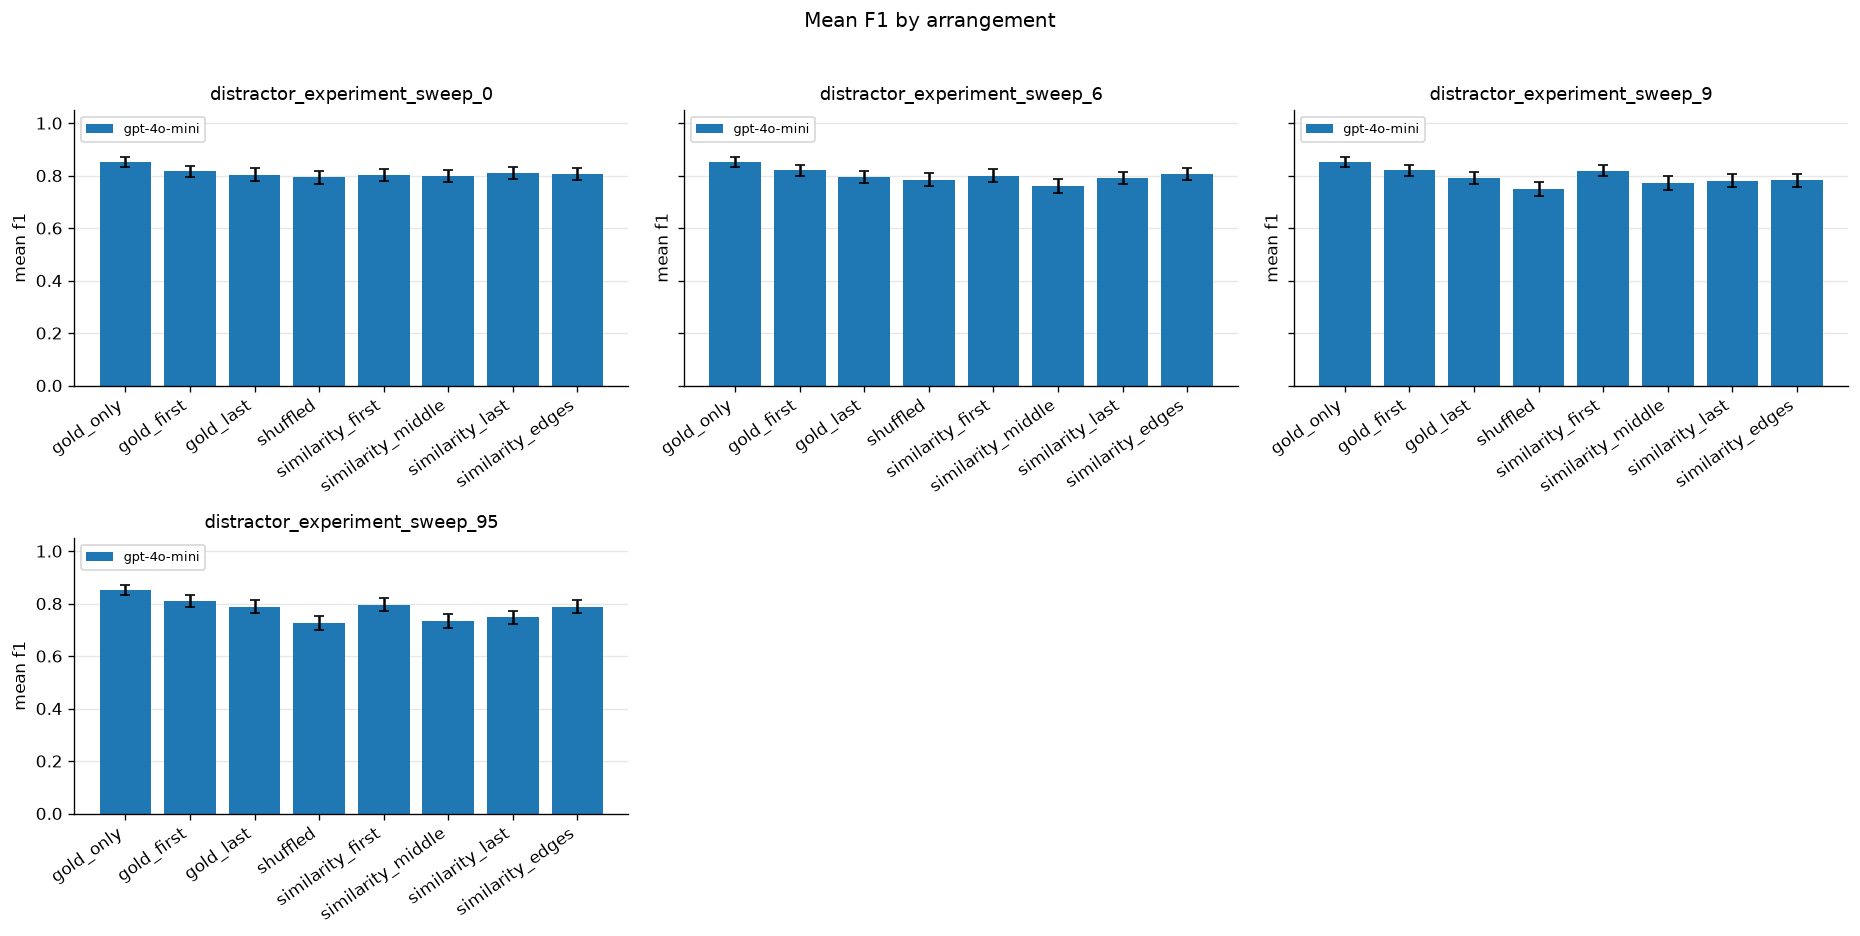

In [8]:
plot_metric_bars(summary_remote, "f1")

### Qwen 3

In [9]:
summary_qwen = summary[
    summary['run_id'].isin(['local_distractor_experiment_sweep_0_qwen',
                            'local_distractor_experiment_sweep_4_qwen'])
    ]

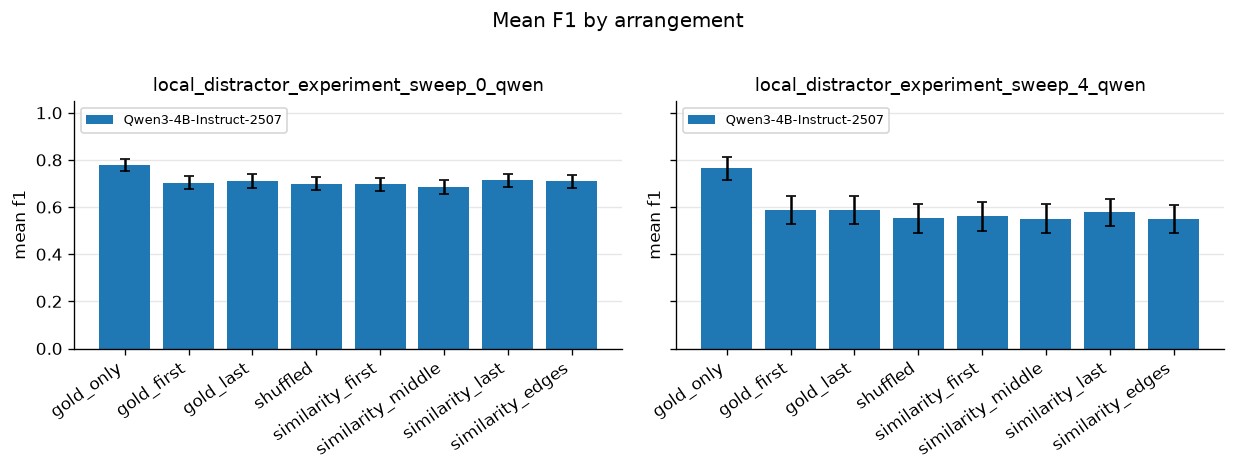

In [10]:
plot_metric_bars(summary_qwen, "f1")

### llama - 1B

In [15]:
summary_llama = summary[
    summary['run_id'].isin(['local_distractor_experiment_sweep_1',
                            'local_distractor_experiment_sweep_0',
                            'ttt_semantic_sweep_llama',
                            'ttt_semantic_sweep_llama_train_first',
                            'ttt_semantic_sweep_llama_train_first_query_only'
                           ])
    ]

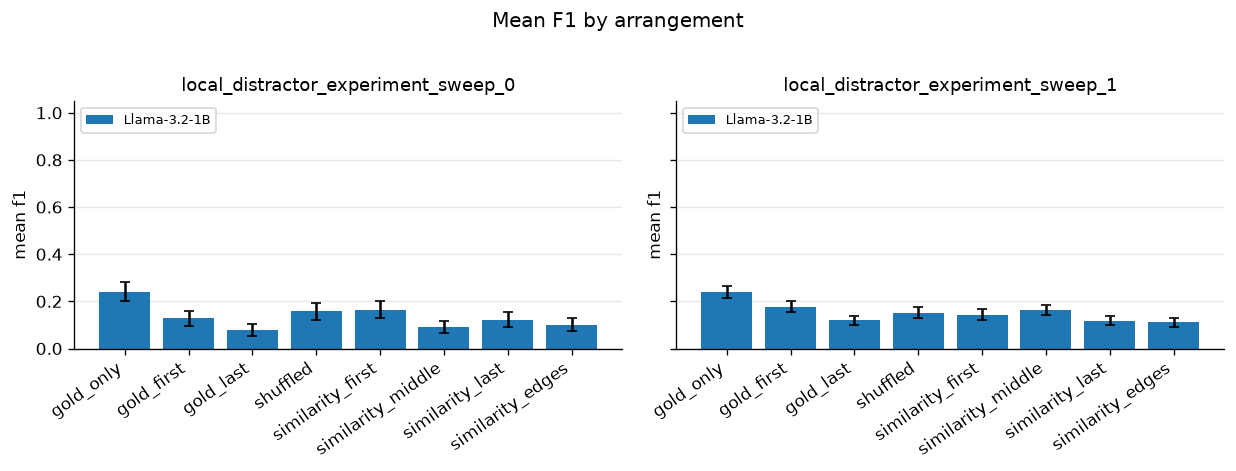

In [16]:
plot_metric_bars(summary_llama, "f1")

### Llama with TTT

In [18]:
summary_TTT = summary[
    summary['run_id'].isin(['ttt_semantic_sweep_llama',
                            'ttt_semantic_sweep_llama_train_first',
                            'ttt_semantic_sweep_llama_train_first_query_only'
                           ])
    ]

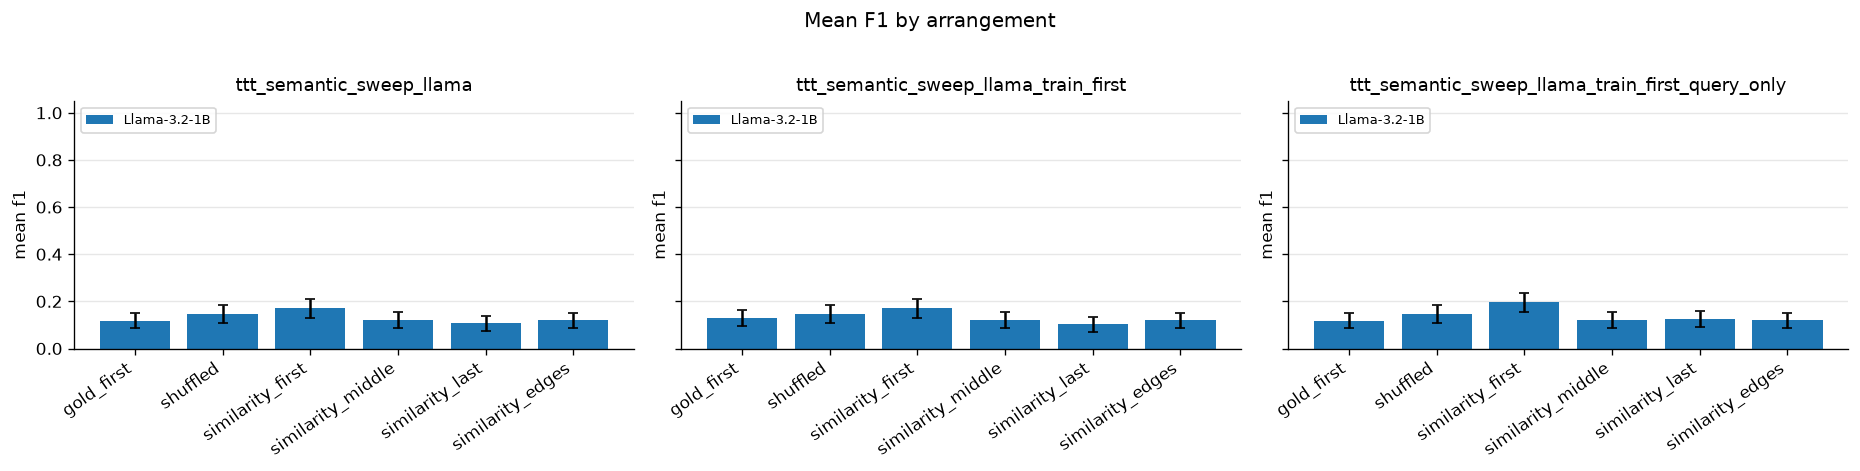

In [19]:
plot_metric_bars(summary_TTT, "f1")